# A brief R intro

## Why program?

Analyzing data, running statistical models, summarizing results, and visualizing findings are central components of the research process. Many psychology students initially prefer point-and-click software. While such tools can be convenient, I strongly recommend investing early in learning a programming language such as **R, Python, or Julia**.

The learning curve can feel steep at first. However, the long-term benefits far outweigh the initial effort—especially today, when AI tools can substantially accelerate learning and troubleshooting.

There are many advantages to programming your analyses. Here are some of the most important:

- **Transparency and Traceability**  
  Code makes every analytical step explicit. You—and others—can rerun the complete analysis from raw data to final results.

- **Reproducibility**  
  When combined with project management tools and version-controlled environments, your analyses remain reproducible even years later.

- **Automation and Scalability**  
  Repetitive tasks can be automated. Analyses can be parallelized and executed on computing clusters, which becomes essential for large datasets or simulation-based methods.

- **Access to Cutting-Edge Methods**  
  The most advanced statistical techniques are typically implemented first in coding environments. Using these tools allows rapid integration of innovative methods.

- **Methodological Independence**  
  Once you gain proficiency, you can implement your own custom analyses instead of being limited to predefined menu options.

- **High-Quality Visualization**  
  Default graphics in many point-and-click tools are often limited in flexibility and aesthetic quality. Libraries such as **ggplot2 (R)** or **seaborn (Python)** enable precise control and publication-ready figures.

- **Transferable Skills**  
  Programming may be one of the most valuable skills you acquire at university. It is highly relevant beyond academia—in research, industry, healthcare, technology, and data science.

In short: programming transforms you from a user of statistical tools into someone who understands and controls the analytical process.

## Why R?

In principle, the specific programming language matters less than the underlying approach. R, Python, and Julia are all powerful environments for data analysis, each with distinct strengths. In this course, we will focus on [R](https://www.r-project.org).

R was developed specifically for statistical computing and data analysis. Its design reflects statistical thinking: models, inference, and visualization are central components of the language. It runs on all major operating systems and is widely used in academia, research, and data science.

A major strength of R is its extensive ecosystem. There are thousands of contributed [R packages](https://r-pkgs.org/introduction.html)—collections of functions designed to solve specific problems. Whether you are conducting classical hypothesis tests, fitting multilevel models, performing Bayesian inference, analyzing time series, or creating publication-quality visualizations, there is typically an established package available.

In practice, this means you are rarely starting from scratch. Most analytical challenges you encounter have already been addressed by the community, allowing you to build on well-tested and continuously maintained tools.

## Running R

When you download R from the official [R Project website](https://www.r-project.org), you install the R interpreter and a very minimal graphical user interface. While this is sufficient to run commands, it is not ideal for structured data analysis or larger projects.

In practice, you will typically use R together with an **Integrated Development Environment (IDE)**.

The most widely used IDE for R is [RStudio](https://posit.co/download/rstudio-desktop/). It is specifically designed for R and provides:

- A script editor with syntax highlighting  
- An integrated console  
- Plot and object viewers  
- Package management  
- Built-in support for projects  
- Seamless integration with R Markdown / Quarto  

For teaching and for beginners, RStudio is generally the most straightforward and stable choice.

Personally, I use [VS Code](https://code.visualstudio.com), a more general-purpose code editor that supports multiple programming languages via extensions. This is particularly useful if you work across different languages (e.g., R, Python, C++). Instructions for configuring R in VS Code can be found [here](https://code.visualstudio.com/docs/languages/r). However, setup is slightly more technical than with RStudio.

---

## Organizing Your Work: Projects and Environments

Regardless of the IDE, it is good practice to organize each analysis as a **project** — a dedicated folder containing:

- All scripts  
- Data (if appropriate)  
- Documentation  
- Configuration files  

I typically create a version-controlled repository on [GitHub](https://github.com) for each project and manage dependencies using a package management system. In fact, I install R itself project-specifically. Currently, I use [pixi](https://pixi.prefix.dev/v0.42.1/).

This approach has an important advantage:  

Installing and updating packages in a global environment can lead to version conflicts, especially if you work on multiple analyses or revisit older projects years later. Project-specific environments ensure that your code remains reproducible and insulated from breaking changes.

If you are using RStudio, you should strongly consider using [renv](https://rstudio.github.io/renv/), which allows each project to maintain its own package library and locked package versions.

# Let's Start simply
I assume you have downloaded R and you are running this notebook within your favorite IDE. Now you can start!

Of course you can use R as a calculator, e.g. adding two numbers.

In [2]:
a <- 1+2
print(a)

[1] 3


Here we assign (using “<-“) the result to the variable “a“, that we can also use for further operations. This could of course mean overwriting an object.

In [4]:
a <- a * 10
print(a)

[1] 30


Of course I could also store multiple values in one object, such as in a vector (i.e., 1xn dimensions), and perform operations on those. For example we could have IQ values of say 100 individuals, and calculate the mean and standard deviation across them.

mean: 101.3561 
sd:   13.69224 


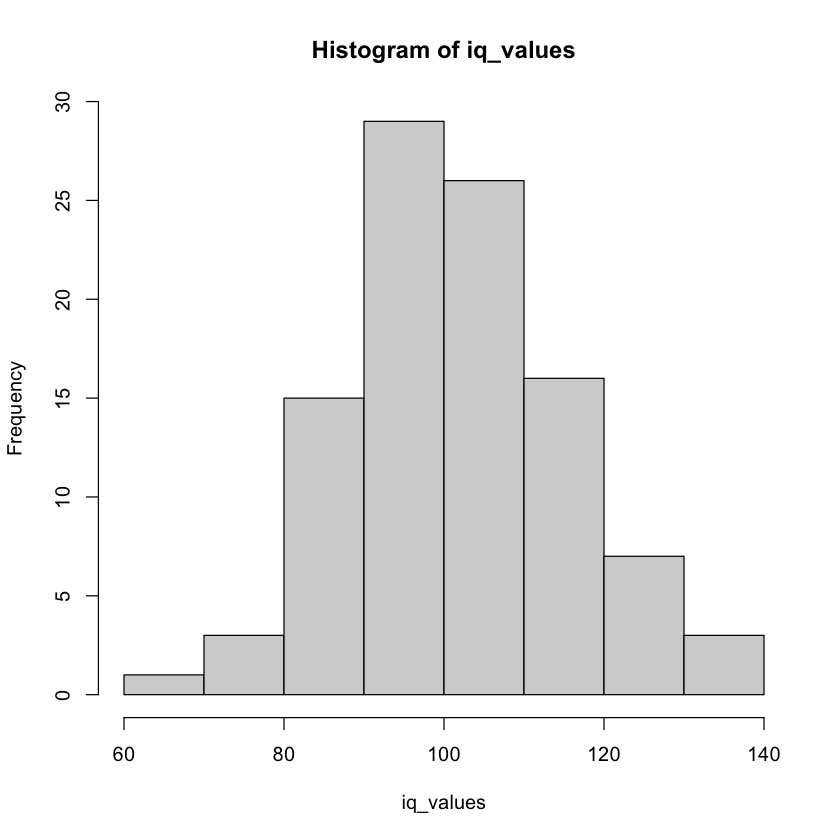

In [17]:
# simulate IQ scores for 20 individuals assuming a normal distribution
set.seed(123)               # for reproducibility
iq_values <- rnorm(100, mean = 100, sd = 15)  # SD 15 is typical for IQ

# inspect the vector and compute summary statistics
hist(iq_values)
cat("mean:", mean(iq_values), "\n")
cat("sd:  ", sd(iq_values), "\n")


## Gaining flexibility by programming own functions

In the example above you saw the commands “mean“ and “sd“ applied to iq_values. These are built-in functions that come with R. Depending on what you want to achieve, there are a gazillion further functions that you can also get via installing packages or by developing your own functions. Let's for example compute our own function to calculate a z-transformation, and then recalculate the mean and sd.

mean of z: 3.130829e-16 
sd of z:   1 


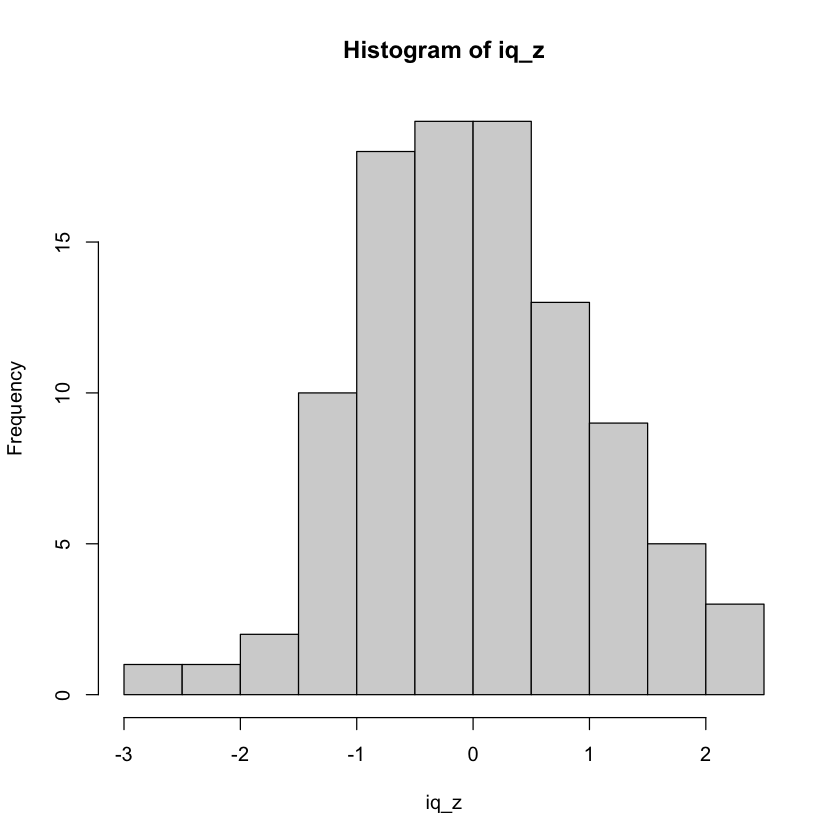

In [ ]:
# define a simple function that returns z‑scores
z_transform <- function(x) {
    (x - mean(x)) / sd(x)
}

# apply it to the previously created iq_values vector
iq_z <- z_transform(iq_values)

# inspect results
hist(iq_z)
cat("mean of z:", mean(iq_z), "\n")
cat("sd of z:  ", sd(iq_z), "\n")

## The typical case in our seminar: 2-D data

The typical scenario in our healthy aging seminar is to get data, in which we have rows of individuals and columns of variables (e.g., age, sex, BMI, WellBeing, etc.). From its setup this is an nxm matrix. We could simulate a matrix of 100 individuals with age (between 20-65), sex (0 = female, 1 = male) and BMI (female average 22, male average 25).

In [22]:
set.seed(123)             # make the example reproducible
n <- 100

sex <- rbinom(n, size = 1, prob = 0.5)            # 0 = female, 1 = male
age <- runif(n, min = 20, max = 65)               # age between 20 and 65
bmi <- rnorm(n, mean = ifelse(sex == 0, 22, 25), sd = 2)

# combine into a plain numeric matrix
sim_matrix <- cbind(age = age,
                    sex = sex,
                    bmi = bmi)

head(sim_matrix)
summary(sim_matrix)

age,sex,bmi
46.99950,0,20.57919
34.97706,1,25.51377
41.98759,0,21.50662
62.95132,1,24.30491
41.73061,1,23.09676
60.06576,0,21.90994


      age             sex            bmi       
 Min.   :20.47   Min.   :0.00   Min.   :17.89  
 1st Qu.:33.77   1st Qu.:0.00   1st Qu.:21.47  
 Median :42.50   Median :0.00   Median :23.24  
 Mean   :43.14   Mean   :0.47   Mean   :23.19  
 3rd Qu.:52.01   3rd Qu.:1.00   3rd Qu.:25.09  
 Max.   :64.35   Max.   :1.00   Max.   :28.69  

As you can see “summary“ already gives me some nice descriptive statistics, but I may be interested in whether the BMI of males differs from females, while controlling for age. We could run a linear regression to test this.

In [23]:
# turn the matrix into a data frame and fit a linear model
sim_df <- as.data.frame(sim_matrix)

model <- lm(bmi ~ sex + age, data = sim_df)
summary(model)


Call:
lm(formula = bmi ~ sex + age, data = sim_df)

Residuals:
    Min      1Q  Median      3Q     Max 
-3.9032 -1.3544 -0.2289  1.1853  6.6737 

Coefficients:
             Estimate Std. Error t value Pr(>|t|)    
(Intercept) 21.873782   0.770452  28.391  < 2e-16 ***
sex          2.973639   0.391799   7.590 1.98e-11 ***
age         -0.001773   0.016557  -0.107    0.915    
---
Signif. codes:  0 ‘***’ 0.001 ‘**’ 0.01 ‘*’ 0.05 ‘.’ 0.1 ‘ ’ 1

Residual standard error: 1.954 on 97 degrees of freedom
Multiple R-squared:  0.3734,	Adjusted R-squared:  0.3604 
F-statistic:  28.9 on 2 and 97 DF,  p-value: 1.431e-10


As you can see the matrix was converted to another object type called “data frame“. We will get to that in a bit. The outcome of the model shows a massive effect of sex, while age does not predict BMI (unrealistic, but hey, we just simulated some data). We can now visualize this effect, e.g. using ggplot2.

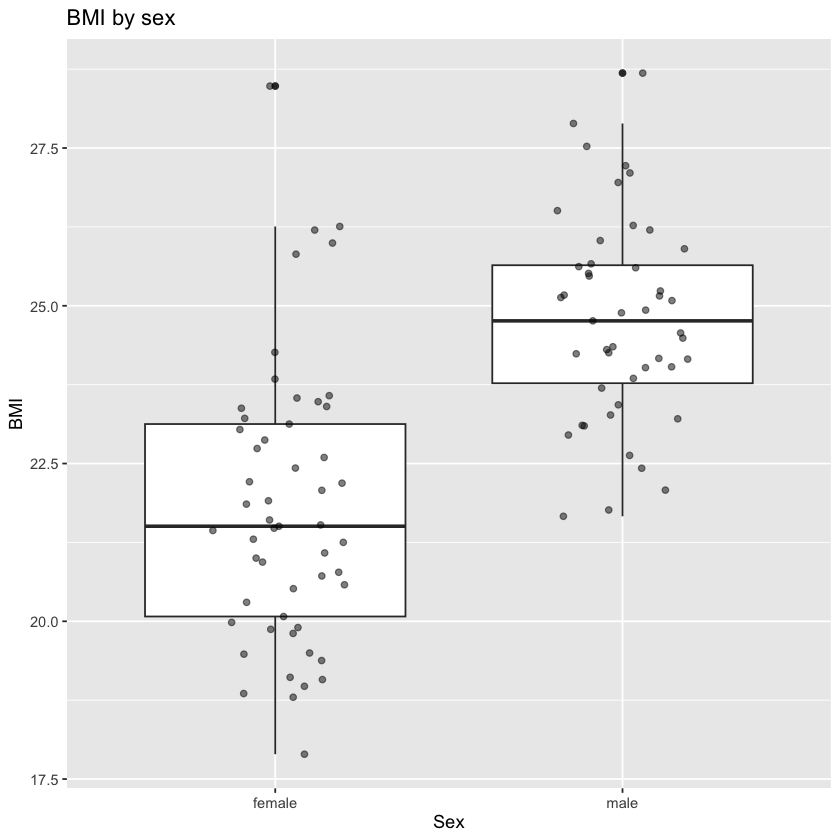

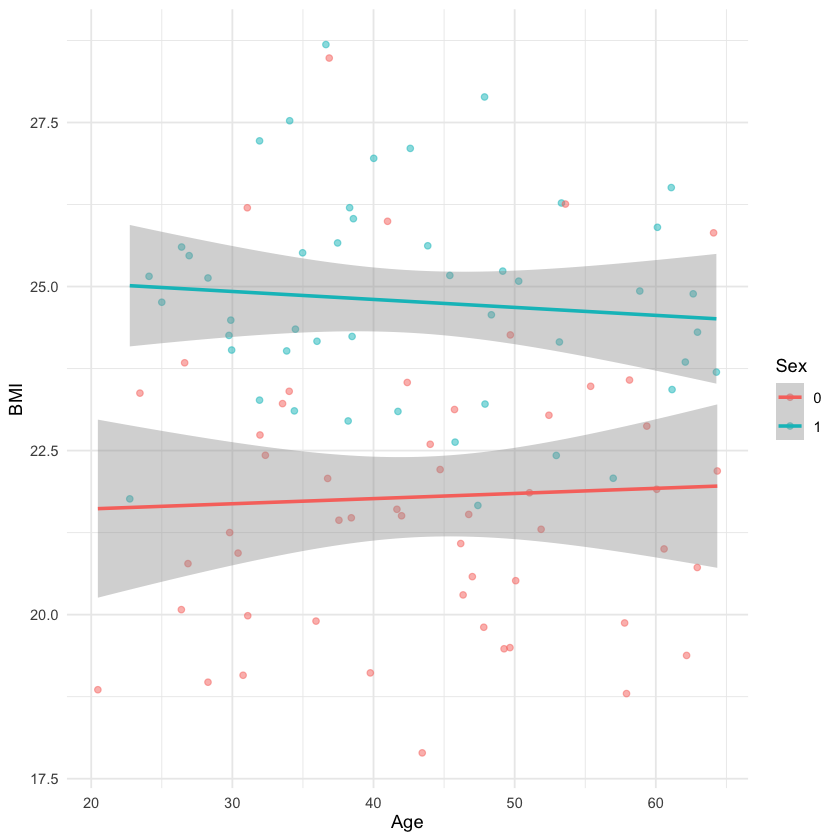

In [ ]:
library(ggplot2)

# boxplot (with jitter) showing the sex difference in BMI
ggplot(sim_df, aes(x = factor(sex), y = bmi)) +
    geom_boxplot() +
    geom_jitter(width = 0.2, alpha = 0.5) +
    scale_x_discrete(labels = c("female", "male")) +
    labs(x = "Sex", y = "BMI", title = "BMI by sex")

# scatter of BMI vs. age with separate regression lines for the two sexes
ggplot(sim_df, aes(x = age, y = bmi, colour = factor(sex))) +
    geom_point(alpha = 0.5) +
    geom_smooth(method = "lm", formula = y ~ x) +
    labs(colour = "Sex", x = "Age", y = "BMI") +
    theme_minimal()

We will return to plotting data later. Just to say that ggplot2 is a very powerful package that enables high degree of fine-tuning possibilities to make your figures as beautiful as possible.

## Data Frames

We introduced matrices above and simulated a case with some “health data“. You noticed that all elements in the matrix were numbers. This is an important limitation of this data structure: all elements need to be of the same type, e.g. all numbers or all strings etc..

While a data frame is also 2-D, *data types can differ between columns*. For example in our simulated data set, we may actually want to code for sex not by 0 and 1, but using strings instead.

In [28]:
# add a column with sex coded as strings instead of 0/1
sim_df$sex_str <- ifelse(sim_df$sex == 0, "female", "male")

# inspect the updated data frame
head(sim_df)
str(sim_df)

,age,sex,bmi,sex_str
,<dbl>,<dbl>,<dbl>,<chr>
1,46.99950,0,20.57919,female
2,34.97706,1,25.51377,male
3,41.98759,0,21.50662,female
4,62.95132,1,24.30491,male
5,41.73061,1,23.09676,male
6,60.06576,0,21.90994,female


'data.frame':	100 obs. of  4 variables:
 $ age    : num  47 35 42 63 41.7 ...
 $ sex    : num  0 1 0 1 1 0 1 1 1 0 ...
 $ bmi    : num  20.6 25.5 21.5 24.3 23.1 ...
 $ sex_str: chr  "female" "male" "female" "male" ...
